# Sparsity study 

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn import tstorch
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
from tsnn.tstorch import transformers
import torch.nn.functional as F
import math
from typing import Optional

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from torch import nn
from tqdm import tqdm
device = 'mps'


plt.style.use('ggplot')

In [2]:
from dataclasses import dataclass

@dataclass
class Config:
    T: int = 4000
    n_ts: int = 10
    n_f: int = 20
    pct_zero_corr: float = 0.5
    split_conditional: float = 0.0
    split_shift: float = 1.0
    split_seasonal: float = 0.0
    split_cs: float = 0.0
    split_cs_shift: float = 0.0
    low_corr: float = 0.05
    high_corr: float = 0.1

In [3]:
z = generators.Generator(Config.T, Config.n_ts, Config.n_f)

In [4]:
%%time
z.generate_dataset(pct_zero_corr = Config.pct_zero_corr,
                  split_conditional = Config.split_conditional,
                  split_shift = Config.split_shift,
                  split_seasonal = Config.split_seasonal,
                  split_cs=Config.split_cs,
                  split_cs_shift=Config.split_cs_shift,
                  low_corr=Config.low_corr, 
                  high_corr=Config.high_corr)

CPU times: user 13.1 ms, sys: 2.95 ms, total: 16.1 ms
Wall time: 19.1 ms


In [5]:
z.get_dataloader(n_rolling=10)

In [6]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [7]:
mask_fn = causal_mask
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,1,1,1,0,0
3,1,1,1,1,0
4,1,1,1,1,1


In [8]:
mask_fn = causal_mask_radius
plot_mask(mask_fn, seq_len=5)

,0,1,2,3,4
0,1,0,0,0,0
1,1,1,0,0,0
2,0,1,1,0,0
3,0,0,1,1,0
4,0,0,0,1,1


In [9]:
from tsnn.tstorch import models

In [10]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

In [11]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

mask = causal_mask
mask = build_attention_mask(mask, 10, device=device)

In [12]:
def keep_topk_per_row(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [13]:
def keep_by_max_value(x, frac=0.1):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out

## List of sparse models

Tried and shown below, I only use a TC model (time + cross sectionnal) and 1 head to make everything simple. I look at a noisy setup of the temporal shift effect.
- Full attention matrix
- Top k coefficients per row of the attention matrix
- Including gated coefficients on each matrix diagonal to get the best MSE while maximizing the sparsity of the attention matrix
- After studying the attention matrix found by the full model, decided to use a method based on the max value of each row to clean the matrix (intuitive since this is a probability space)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:19<00:00,  1.00it/s]


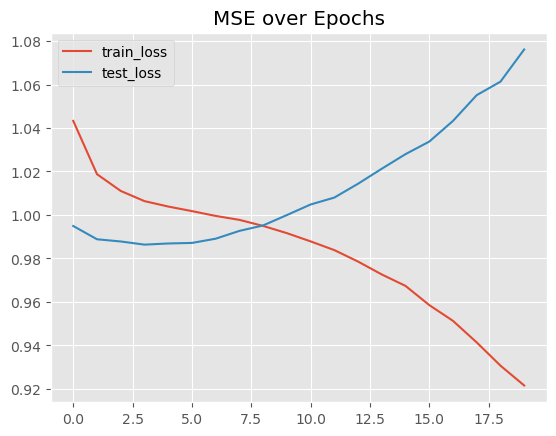

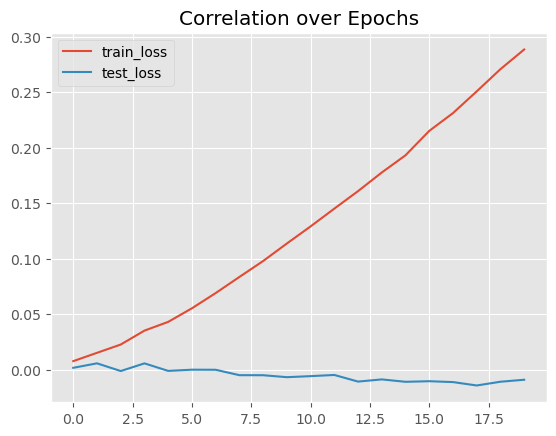

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.10it/s]


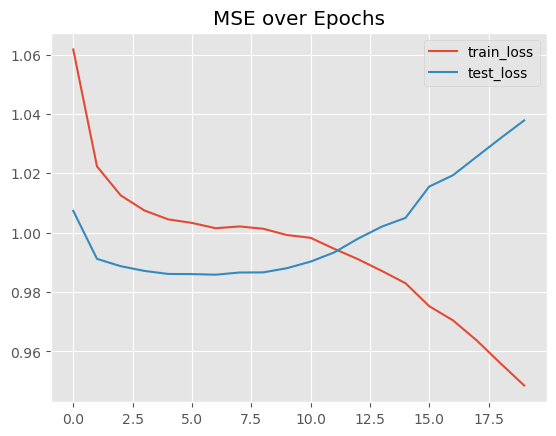

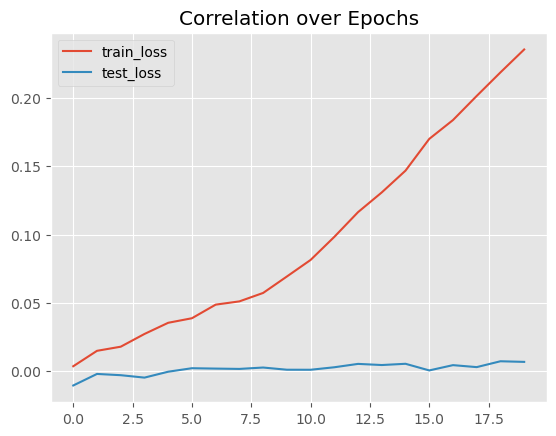

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.08it/s]


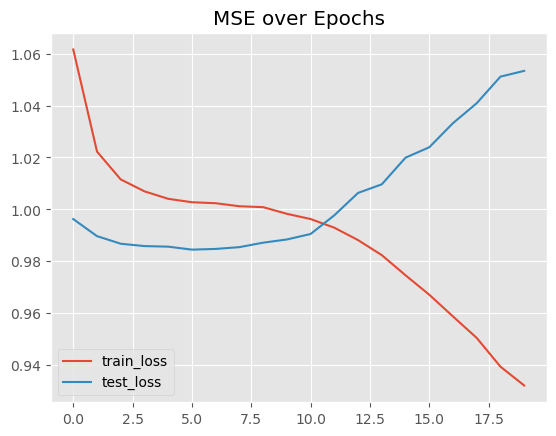

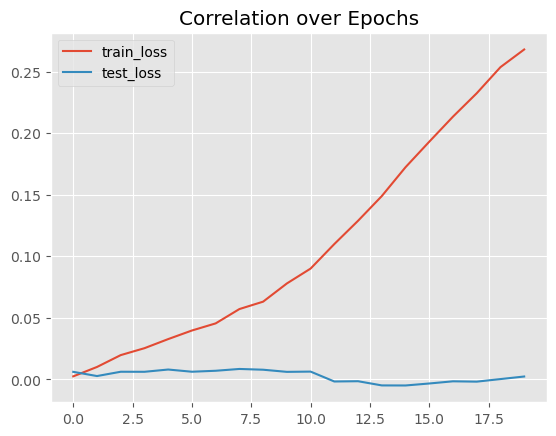

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:19<00:00,  1.02it/s]


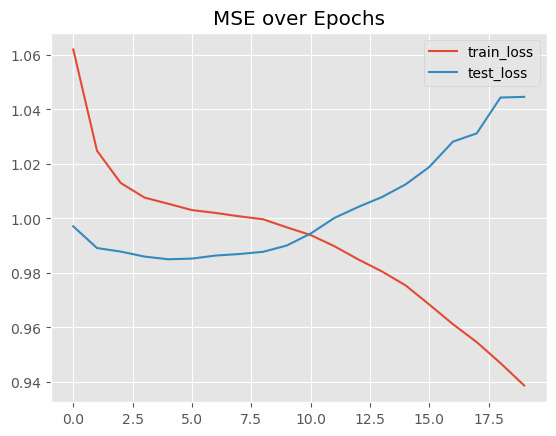

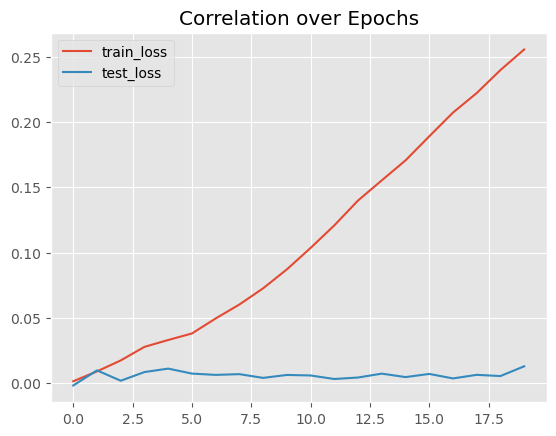

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:22<00:00,  1.11s/it]


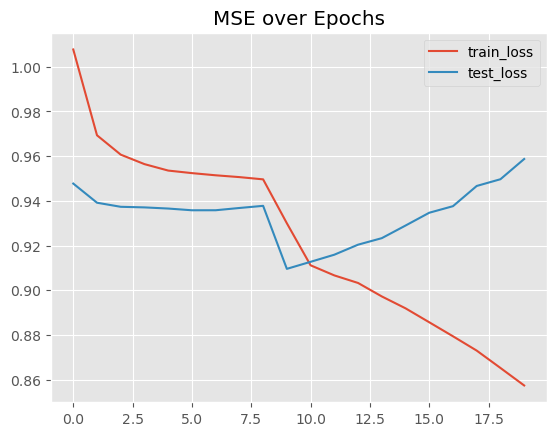

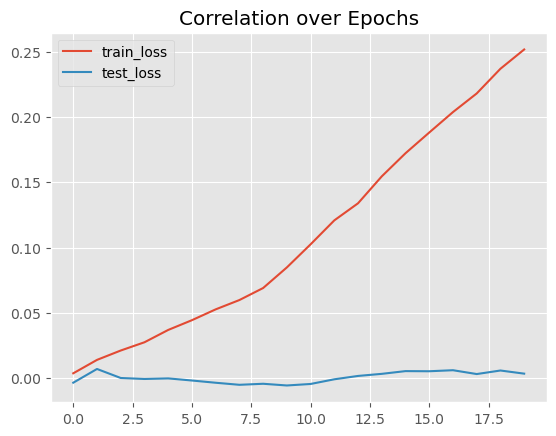

Gated coefficients for sparse model:
Layer 0: [0.         0.18909648 0.16507684 0.         0.         0.
 0.16253611 0.16101693 0.16134372 0.16092995]


,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.031,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.031,1.000,nan,nan,nan,nan,nan,nan,nan,nan
lasso,0.174,0.148,0.148,nan,nan,nan,nan,nan,nan,nan
boosting,0.697,0.044,0.044,0.231,nan,nan,nan,nan,nan,nan
mlp,0.994,0.034,0.034,0.175,0.694,nan,nan,nan,nan,nan
full_attention,0.341,0.079,0.079,0.107,0.243,0.339,nan,nan,nan,nan
deterministic_sparse,0.272,0.175,0.175,0.128,0.205,0.271,0.286,nan,nan,nan
top_k_sparse,0.311,0.138,0.138,0.119,0.219,0.310,0.316,0.340,nan,nan
max_sparse,0.295,0.216,0.216,0.125,0.216,0.294,0.275,0.335,0.342,nan
dynamic_sparse,0.290,0.131,0.131,0.107,0.209,0.289,0.322,0.298,0.362,0.304


,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse,max_sparse
optimal,0.018,nan,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.018,1.000,nan,nan,nan,nan,nan,nan,nan,nan
lasso,0.001,0.139,0.139,nan,nan,nan,nan,nan,nan,nan
boosting,0.013,0.038,0.038,0.208,nan,nan,nan,nan,nan,nan
mlp,0.003,0.072,0.072,0.370,0.130,nan,nan,nan,nan,nan
full_attention,-0.014,0.074,0.074,0.042,0.017,0.032,nan,nan,nan,nan
deterministic_sparse,0.006,0.174,0.174,0.074,0.026,0.054,0.215,nan,nan,nan
top_k_sparse,0.002,0.160,0.160,0.056,0.013,0.045,0.251,0.294,nan,nan
max_sparse,0.010,0.216,0.216,0.064,0.019,0.050,0.199,0.271,0.282,nan
dynamic_sparse,0.004,0.131,0.131,0.055,0.019,0.050,0.244,0.251,0.307,0.254


In [14]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
        'dynamic_sparse': sparse_model,
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    # gated coefs print
    print("Gated coefficients for sparse model:")
    gated_coeffs = models_torch['dynamic_sparse'].model.get_gated_coeffs()
    for i, coeffs in enumerate(gated_coeffs):
        print(f"Layer {i}: {coeffs.detach().cpu().numpy()}")
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix

In [68]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.778,0.222,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.173,0.605,0.223,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.147,0.077,0.581,0.195,0.000,0.000,0.000,0.000,0.000,0.000
4,0.090,0.089,0.056,0.627,0.138,0.000,0.000,0.000,0.000,0.000
5,0.092,0.053,0.074,0.059,0.550,0.171,0.000,0.000,0.000,0.000
6,0.033,0.054,0.031,0.082,0.062,0.611,0.127,0.000,0.000,0.000
7,0.024,0.056,0.039,0.087,0.025,0.074,0.549,0.146,0.000,0.000
8,0.023,0.018,0.046,0.056,0.054,0.098,0.043,0.527,0.135,0.000
9,0.026,0.018,0.037,0.031,0.039,0.083,0.054,0.048,0.544,0.119


Sparsity matrix with the max proba algorithm

In [16]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.586,0.414,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.640,0.360,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.742,0.258,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.603,0.397,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.573,0.427,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.685,0.315,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.648,0.352,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.600,0.400


Preliminary conclusions:
- dynamic sparse seems to find the right coefficients but doesn't show a high improvement over the full attention. also there are some choices here of loss functions etc which may not be optimal
- the 2 sparse methods seem better than full and (expected) right below the informed model where we enforce the correct sparsity
- max_sparse is more stable (to confirm in bootstrap)

## TCTC models with temporal shift effect

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.78s/it]


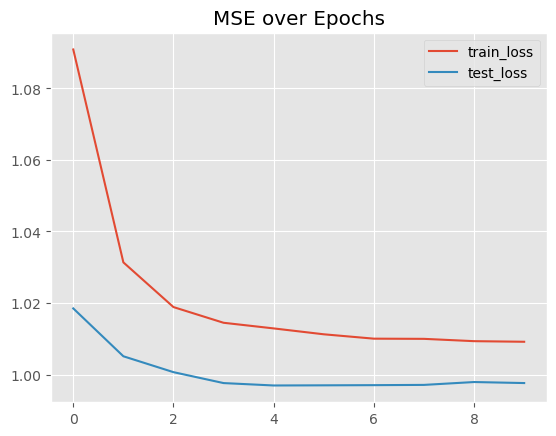

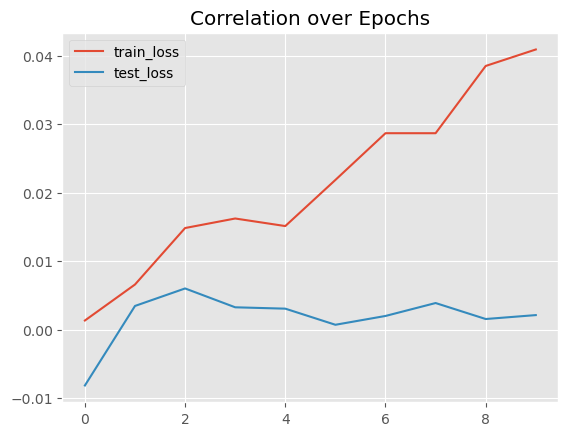

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.66s/it]


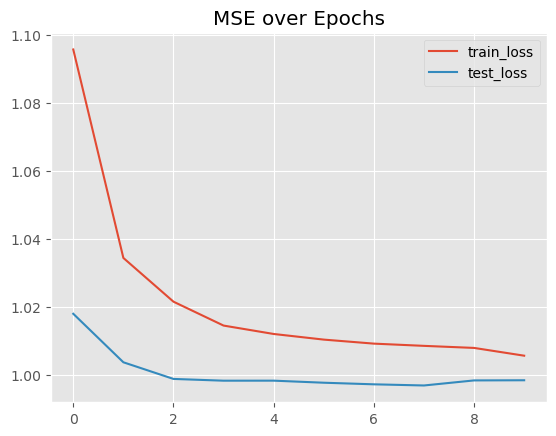

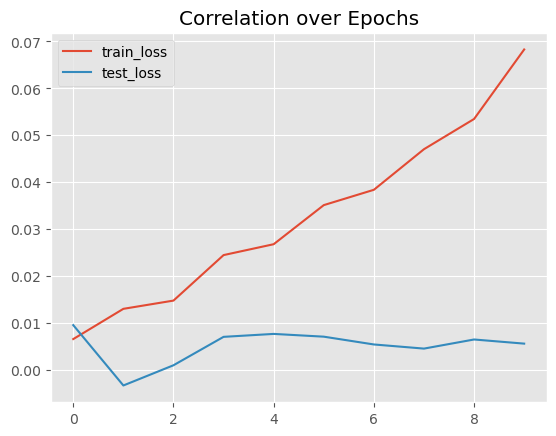

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:17<00:00,  1.70s/it]


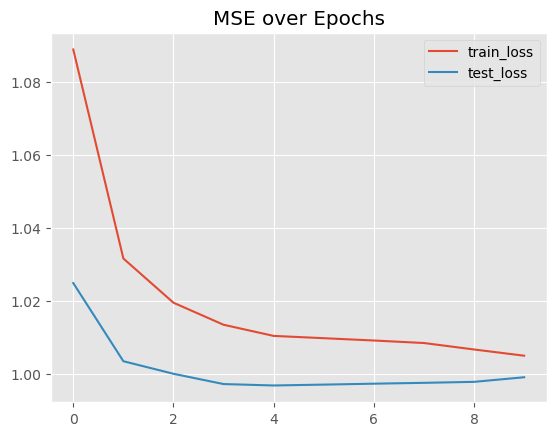

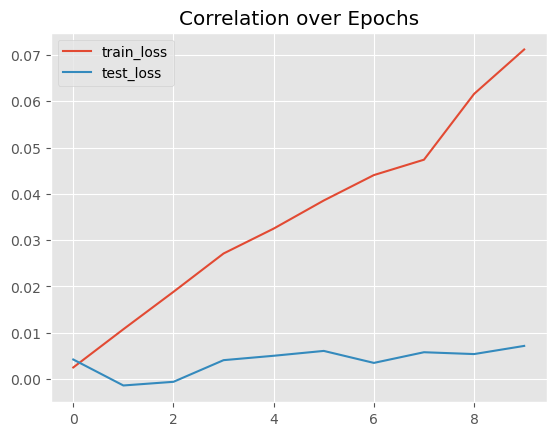

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:16<00:00,  1.64s/it]


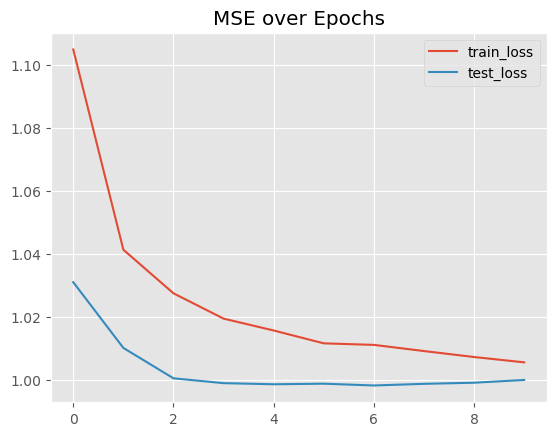

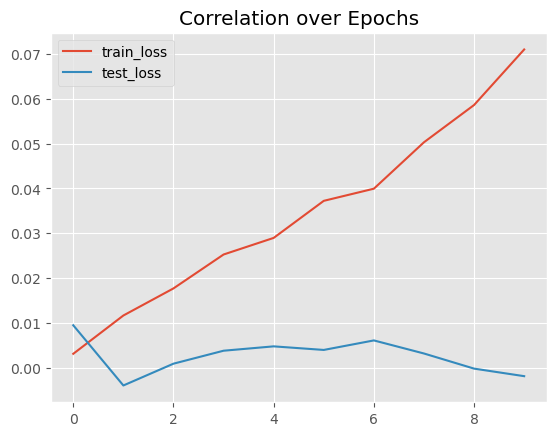

,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.023,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.023,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,0.164,0.099,0.099,nan,nan,nan,nan,nan,nan
boosting,0.695,0.024,0.024,0.194,nan,nan,nan,nan,nan
mlp,0.994,0.025,0.025,0.164,0.691,nan,nan,nan,nan
full_attention,0.070,0.006,0.006,0.033,0.059,0.069,nan,nan,nan
deterministic_sparse,0.108,0.093,0.093,0.053,0.086,0.107,0.552,nan,nan
top_k_sparse,0.113,0.215,0.215,0.079,0.093,0.112,0.495,0.595,nan
max_sparse,0.119,0.069,0.069,0.073,0.099,0.119,0.510,0.626,0.593


,true,optimal,shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.026,nan,nan,nan,nan,nan,nan,nan,nan
shift,0.026,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,0.008,0.077,0.077,nan,nan,nan,nan,nan,nan
boosting,-0.005,0.017,0.017,0.147,nan,nan,nan,nan,nan
mlp,0.014,0.047,0.047,0.349,0.107,nan,nan,nan,nan
full_attention,-0.002,0.004,0.004,0.012,0.016,0.027,nan,nan,nan
deterministic_sparse,0.003,0.090,0.090,0.034,0.021,0.050,0.538,nan,nan
top_k_sparse,0.009,0.220,0.220,0.061,0.019,0.047,0.479,0.587,nan
max_sparse,-0.006,0.058,0.058,0.030,0.017,0.030,0.493,0.615,0.585


In [15]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TCTC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=10)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

Full attention matrix FIRST layer

In [73]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.643,0.357,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.537,0.410,0.053,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.426,0.411,0.066,0.097,0.000,0.000,0.000,0.000,0.000,0.000
4,0.121,0.128,0.136,0.332,0.283,0.000,0.000,0.000,0.000,0.000
5,0.099,0.085,0.064,0.206,0.339,0.206,0.000,0.000,0.000,0.000
6,0.133,0.139,0.166,0.163,0.105,0.162,0.133,0.000,0.000,0.000
7,0.131,0.084,0.061,0.164,0.104,0.140,0.199,0.117,0.000,0.000
8,0.140,0.136,0.040,0.083,0.082,0.102,0.121,0.232,0.063,0.000
9,0.116,0.103,0.037,0.081,0.091,0.093,0.110,0.244,0.059,0.067


Full attention matrix SECOND layer

In [74]:
pd.DataFrame(np.array(models_torch['full_attention'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.654,0.346,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.443,0.386,0.172,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.310,0.189,0.327,0.174,0.000,0.000,0.000,0.000,0.000,0.000
4,0.225,0.118,0.226,0.246,0.185,0.000,0.000,0.000,0.000,0.000
5,0.156,0.105,0.133,0.128,0.180,0.298,0.000,0.000,0.000,0.000
6,0.141,0.116,0.193,0.078,0.165,0.204,0.103,0.000,0.000,0.000
7,0.123,0.076,0.125,0.120,0.116,0.182,0.168,0.089,0.000,0.000
8,0.131,0.045,0.074,0.090,0.111,0.207,0.093,0.087,0.162,0.000
9,0.095,0.076,0.065,0.075,0.082,0.143,0.099,0.108,0.158,0.101


Sparsity matrix with the max proba algorithm FIRST layer

In [37]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.416,0.584,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.456,0.544,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.441,0.559,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.468,0.532,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.499,0.501,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.498,0.502,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.502,0.498,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.609,0.391,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.560,0.440


Sparsity matrix with the max proba algorithm SECOND layer

In [39]:
pd.DataFrame(np.array(models_torch['max_sparse'].model.blocks[2].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.525,0.475,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.497,0.503,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.547,0.453,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.571,0.429,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.495,0.505,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.498,0.502,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.504,0.496,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.608,0.392,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.590,0.410


## Cross-sectionnal effect

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.08it/s]


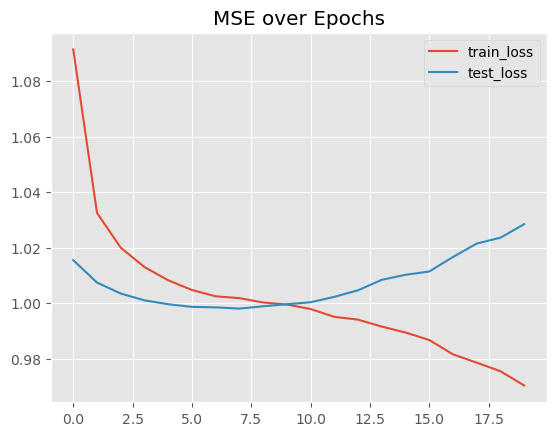

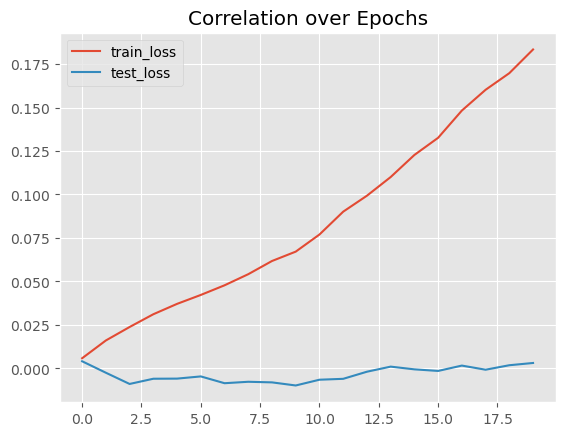

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.11it/s]


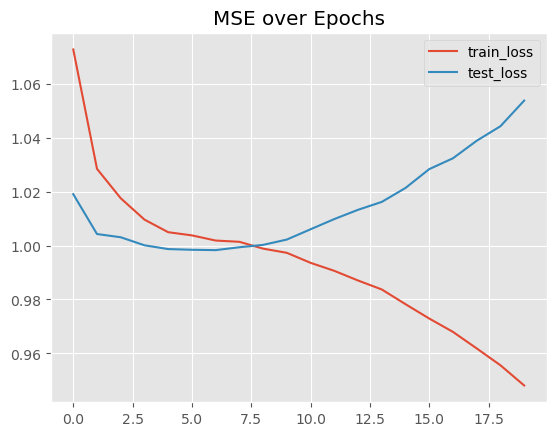

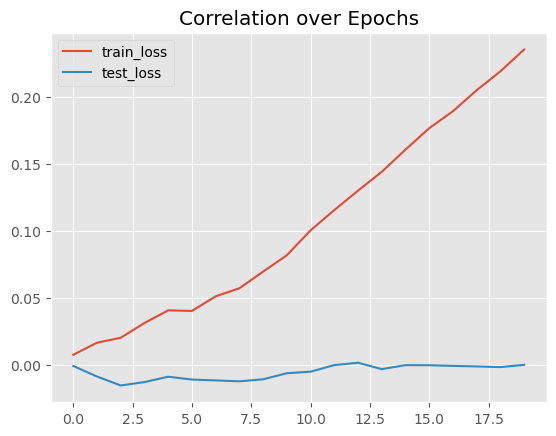

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.07it/s]


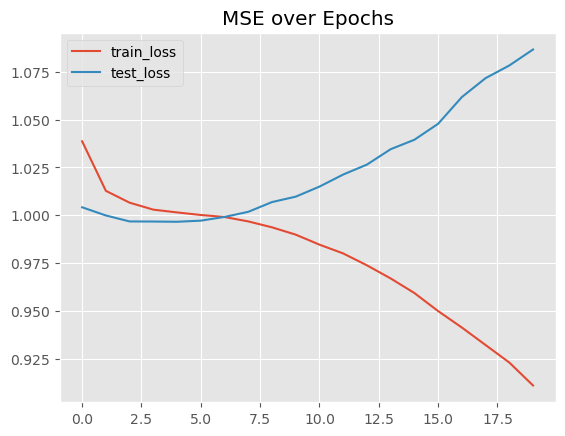

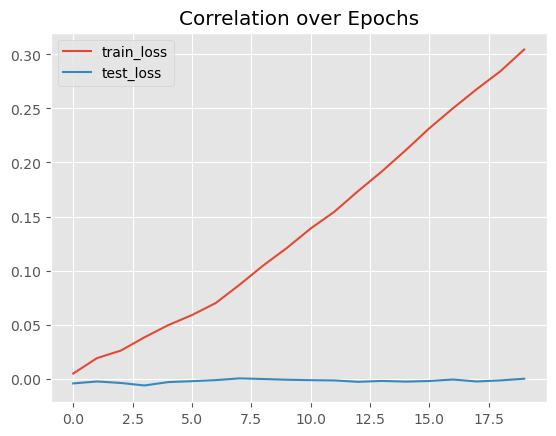

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.08it/s]


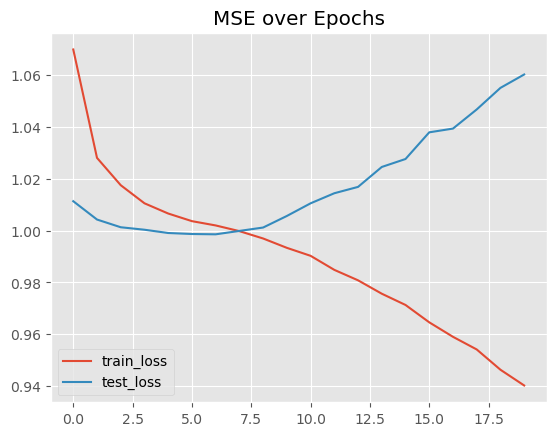

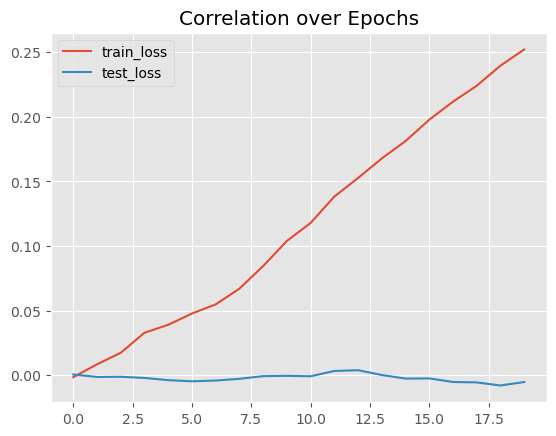

,true,optimal,cs,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.034,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.034,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,0.166,0.020,0.020,nan,nan,nan,nan,nan,nan
boosting,0.693,0.025,0.025,0.188,nan,nan,nan,nan,nan
mlp,0.993,0.035,0.035,0.167,0.687,nan,nan,nan,nan
full_attention,0.214,0.068,0.068,0.095,0.165,0.211,nan,nan,nan
deterministic_sparse,0.277,0.057,0.057,0.087,0.215,0.273,0.330,nan,nan
top_k_sparse,0.354,0.047,0.047,0.099,0.256,0.350,0.314,0.348,nan
max_sparse,0.292,0.073,0.073,0.095,0.211,0.288,0.276,0.326,0.298


,true,optimal,cs,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.044,nan,nan,nan,nan,nan,nan,nan,nan
cs,0.044,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,-0.008,0.009,0.009,nan,nan,nan,nan,nan,nan
boosting,-0.007,0.005,0.005,0.143,nan,nan,nan,nan,nan
mlp,0.011,0.023,0.023,0.342,0.096,nan,nan,nan,nan
full_attention,0.006,0.044,0.044,0.039,0.003,0.031,nan,nan,nan
deterministic_sparse,0.003,0.061,0.061,0.030,0.021,0.027,0.283,nan,nan
top_k_sparse,-0.000,0.043,0.043,0.035,0.025,0.037,0.269,0.280,nan
max_sparse,-0.002,0.047,0.047,0.048,0.017,0.026,0.246,0.280,0.229


In [16]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.01]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 1.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

## CS + tempporal shift

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.12it/s]


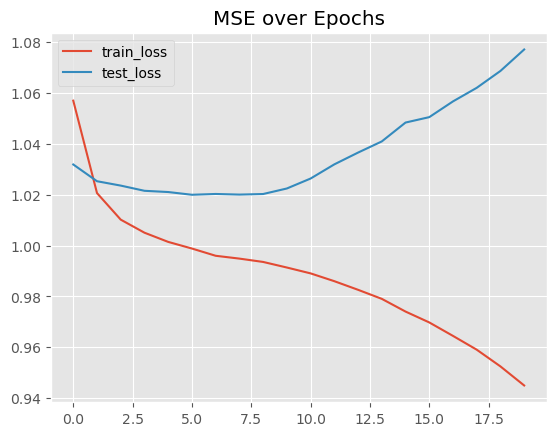

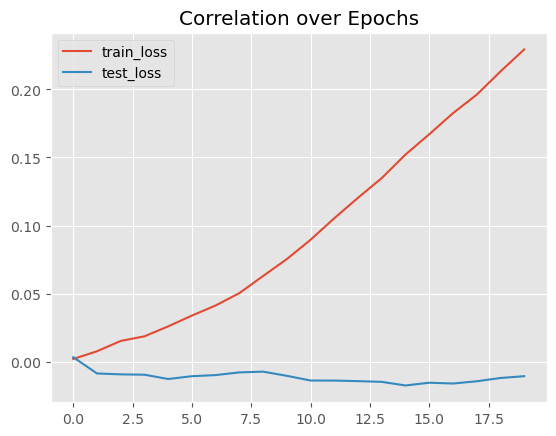

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.08it/s]


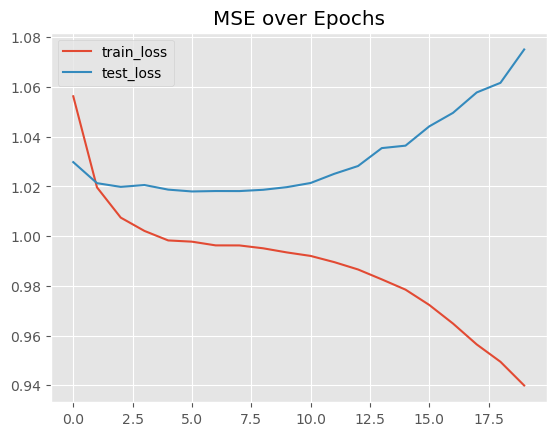

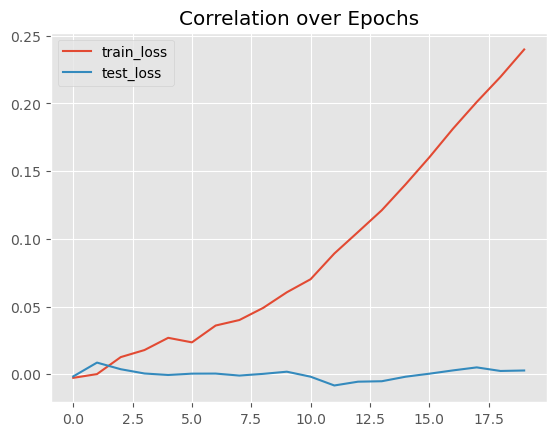

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.13it/s]


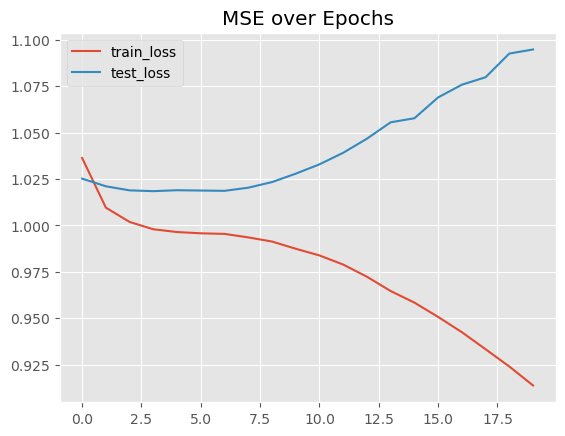

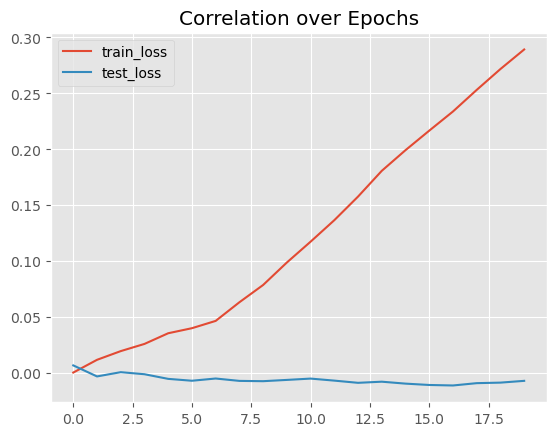

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:17<00:00,  1.11it/s]


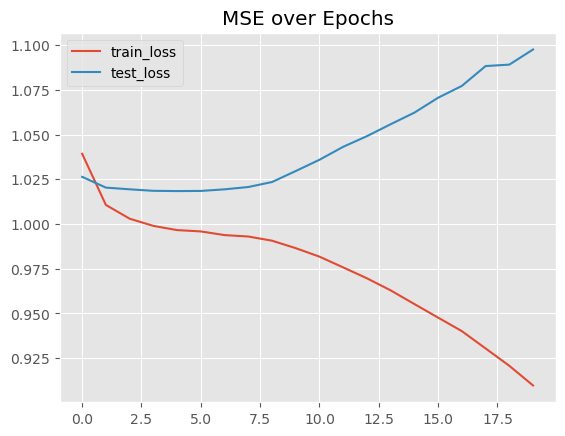

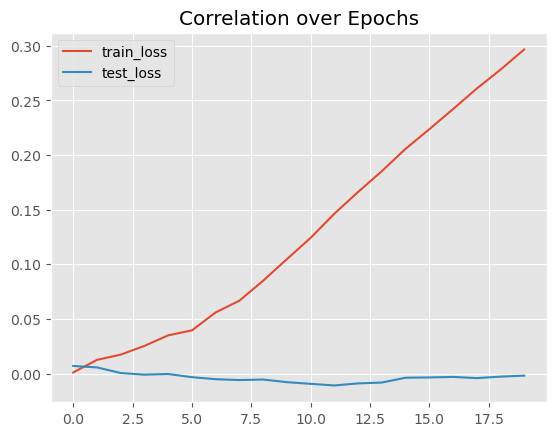

,true,optimal,cs_shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.092,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.092,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,0.177,0.718,0.718,nan,nan,nan,nan,nan,nan
boosting,0.693,0.161,0.161,0.252,nan,nan,nan,nan,nan
mlp,0.981,0.093,0.093,0.176,0.678,nan,nan,nan,nan
full_attention,0.275,0.035,0.035,0.066,0.191,0.268,nan,nan,nan
deterministic_sparse,0.280,0.072,0.072,0.093,0.206,0.273,0.260,nan,nan
top_k_sparse,0.345,0.044,0.044,0.080,0.233,0.337,0.300,0.297,nan
max_sparse,0.340,0.051,0.051,0.088,0.235,0.332,0.284,0.304,0.323


,true,optimal,cs_shift,lasso,boosting,mlp,full_attention,deterministic_sparse,top_k_sparse
optimal,0.099,nan,nan,nan,nan,nan,nan,nan,nan
cs_shift,0.099,1.000,nan,nan,nan,nan,nan,nan,nan
lasso,0.069,0.721,0.721,nan,nan,nan,nan,nan,nan
boosting,0.002,0.201,0.201,0.257,nan,nan,nan,nan,nan
mlp,0.024,0.164,0.164,0.300,0.114,nan,nan,nan,nan
full_attention,-0.010,0.001,0.001,0.010,-0.003,0.016,nan,nan,nan
deterministic_sparse,0.002,0.044,0.044,0.041,0.010,0.022,0.197,nan,nan
top_k_sparse,-0.005,0.004,0.004,0.006,-0.009,0.005,0.239,0.247,nan
max_sparse,-0.003,0.004,0.004,0.009,-0.004,0.007,0.221,0.231,0.245


In [17]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.03]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 1.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    # param for regularization
    lambda_l1_value = 0.5
    
    sparse_model = models.CustomBiDimensionalTransformerSparse(
        Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC',
        dropout=0.1, dim_feedforward=256, sparsify=None, nhead=1,
        lambda_l1=lambda_l1_value, roll_y=True
    ).to(device)
    
    # loss fct with l1 norm
    loss_fn = MSELossWithL1Sparsity(model=sparse_model, lambda_l1=lambda_l1_value)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'deterministic_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        
        'top_k_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
        ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

## Bootstrapping

In [19]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


def run_bootstrap(c, effect, n=40, T=4000, n_ts=10, n_f=20, models_torch=None, epochs=15):
    arg_list = {'d_lin': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cond': {'pct_zero_corr': 0.5, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
                'd_shift': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cs': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
                'd_cs_shift': {'pct_zero_corr': 0.5, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
                'd_all': {'pct_zero_corr': 0.5, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
               }
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []
    for i in tqdm(range(n)):
        z.generate_dataset(
                pct_zero_corr=arg_list[effect]['pct_zero_corr'],
                split_conditional=arg_list[effect]['split_conditional'],
                split_shift=arg_list[effect]['split_shift'],
                split_seasonal=arg_list[effect]['split_seasonal'],
                split_cs=arg_list[effect]['split_cs'],
                split_cs_shift=arg_list[effect]['split_cs_shift'],
                
                low_corr=c,
                high_corr=c,
            )

        z.get_dataloader()
        
        models_linear = {'lasso': ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                          verbose=False, max_iter=1000, selection='random', n_jobs=5, cv=3)),
                         'boosting': ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, 
                                                                                                        n_iter_no_change=100))}
        # models_linear = {}


        models_torch = {
            'full_attention': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_c, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
            ).to(device),
            'deterministic_sparse': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_1, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
            ).to(device),

            'top_k_sparse': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_1, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
            ).to(device),

            'max_sparse': models.CustomBiDimensionalTransformer(
                n_ts, n_f, 10, mask=mask_1, layers='TC', nhead=1,
                dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
            ).to(device),
        }


        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
                device=device
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=10, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=epochs, plot=False, verbose=0)
            
        for k in models_linear:
            models_linear[k].fit(z.train)

        comp = benchmark_comparison.Comparator(models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch], 
        model_names=[k for k in models_linear] + [k for k in models_torch]
        )
        
        # display(comp.correl(z, mode="test"))
        
        res_train.append(comp.correl(z, mode="train", return_values=True)['optimal'])
        res_test.append(comp.correl(z, mode="test", return_values=True)['optimal'])
        
    return res_train, res_test

############## WARNING TAKES TIME TO RUN ######

In [ ]:
cs = [0.005, 
      # 0.01
     ]
effects = [
    'd_shift', 
           'd_cs', 'd_cs_shift', 
           'd_all',
           'd_cond', 'd_lin'
          ]

import warnings

for c in cs:
    for effect in effects:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(c, effect, n=30, n_ts=10, n_f=20)
        pd.concat(r_train, axis=1).T.to_parquet(f'sparse_results/sparse_{effect}_{c}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'sparse_results/sparse_{effect}_{c}_test.parquet')

 83%|██████████████████████████████████████████████████████████████████████████████████████████▊                  | 25/30 [34:40<07:07, 85.40s/it]

In [ ]:
cs = [0.005, 0.01, 0.03]
effects = ['d_shift', 'd_cs', 'd_cs_shift', 
           'd_all',
           'd_cond', 'd_lin'
          ]

import warnings

for c in cs:
    for effect in effects:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(c, effect, n=30, n_ts=20, n_f=10)
        pd.concat(r_train, axis=1).T.to_parquet(f'sparse_results2/sparse_{effect}_{c}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'sparse_results2/sparse_{effect}_{c}_test.parquet')

## DRAFT

In [42]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:13<00:00,  1.08it/s]


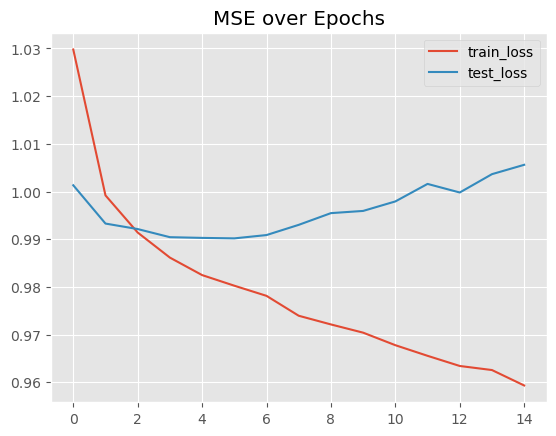

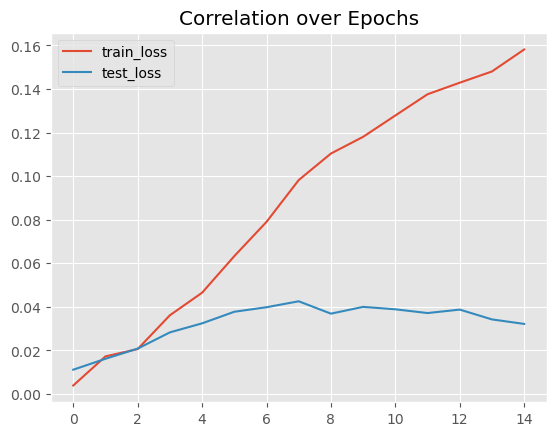

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:09<00:00,  1.56it/s]


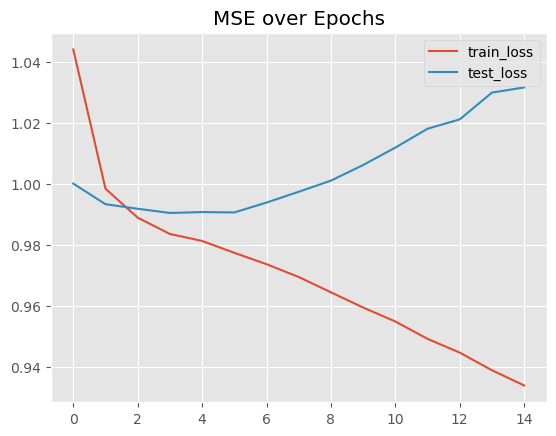

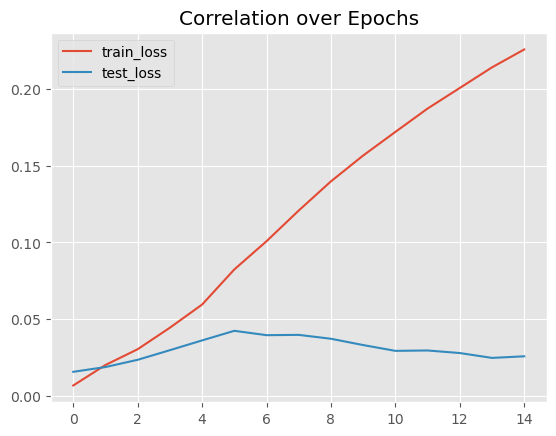

,true,optimal,cs,lasso,boosting,mlp,full_attention
optimal,0.117,nan,nan,nan,nan,nan,nan
cs,0.117,1.000,nan,nan,nan,nan,nan
lasso,0.117,0.268,0.268,nan,nan,nan,nan
boosting,0.672,0.105,0.105,0.192,nan,nan,nan
mlp,0.983,0.117,0.117,0.121,0.662,nan,nan
full_attention,0.180,0.264,0.264,0.235,0.141,0.180,nan
CC,0.246,0.259,0.259,0.175,0.190,0.243,0.358


,true,optimal,cs,lasso,boosting,mlp,full_attention
optimal,0.102,nan,nan,nan,nan,nan,nan
cs,0.102,1.000,nan,nan,nan,nan,nan
lasso,0.028,0.268,0.268,nan,nan,nan,nan
boosting,0.004,0.052,0.052,0.197,nan,nan,nan
mlp,0.001,0.038,0.038,0.169,0.056,nan,nan
full_attention,0.039,0.231,0.231,0.214,0.024,0.044,nan
CC,0.025,0.228,0.228,0.139,0.026,0.030,0.319


In [59]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.05]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 10
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 1.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr,
        shuffle_cs=True
    )
    
    z.get_dataloader(n_rolling=10)
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
        'CC': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='CC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        # 'max_sparse': models.CustomBiDimensionalTransformer(
        #     Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
        #     dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        # ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 10, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss(),
            device=device
        ) for k in models_no_roll
    }
    models_no_roll = {}

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=15)
    
    # z.get_dataloader(n_rolling=10, roll_y=False)
    # for k in models_no_roll:
    #     models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

In [20]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmark(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmark(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmark(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

In [61]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 2, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 2, device=device)


for c in [0.03]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 20
        pct_zero_corr: float = 0.5
        split_conditional: float = 1.0
        split_shift: float = 0.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr
    )
    
    z.get_dataloader()
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 2, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        'max_sparse': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 2, mask=mask_1, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 2, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss(),
            device=device
        ) for k in models_no_roll
    }

    
    z.get_dataloader(n_rolling=2, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=20)
    
    z.get_dataloader(n_rolling=2, roll_y=False)
    for k in models_no_roll:
        models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))

 50%|██████████████████████████████████████████████████████▌                                                      | 10/20 [00:04<00:04,  2.40it/s]


KeyboardInterrupt: 

In [48]:
# models_linear = {'lasso': ml_benchmarks.LassoBenchmark()}

lasso_full = ml_benchmarks.CustomBenchmarkRolling(LassoCV(alphas=np.linspace(start=1e-4, stop=1e-2, num=30), 
                                                            verbose=False, max_iter=2000, selection='random', n_jobs=5, cv=3))
    
boost_model = ml_benchmarks.CustomBenchmarkRolling(HistGradientBoostingRegressor(max_depth=6, max_iter=500, validation_fraction=0.3, n_iter_no_change=100))

mlp_model = ml_benchmarks.CustomBenchmarkRolling(MLPRegressor())

models_linear = {'lasso': lasso_full, 'boosting': boost_model, 'mlp': mlp_model}

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:13<00:00,  1.10it/s]


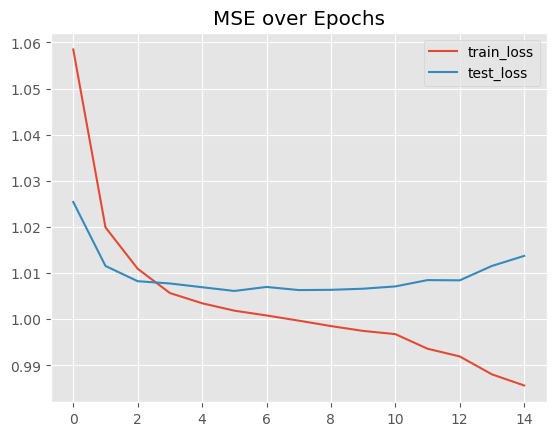

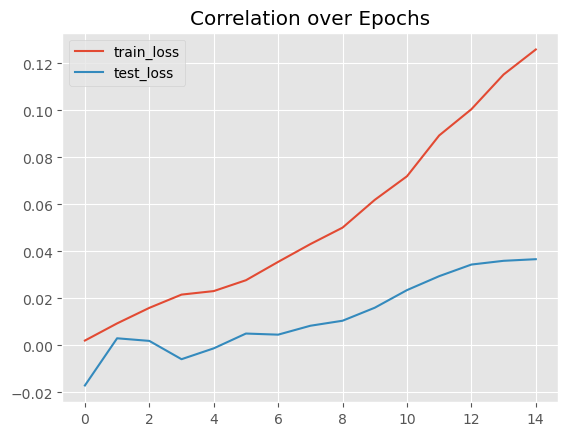

,true,optimal,shift,lasso,boosting,mlp
optimal,0.112,nan,nan,nan,nan,nan
shift,0.112,1.000,nan,nan,nan,nan
lasso,0.151,0.903,0.903,nan,nan,nan
boosting,0.679,0.292,0.292,0.338,nan,nan
mlp,0.985,0.113,0.113,0.152,0.670,nan
full_attention,0.156,0.267,0.267,0.258,0.174,0.153


,true,optimal,shift,lasso,boosting,mlp
optimal,0.102,nan,nan,nan,nan,nan
shift,0.102,1.000,nan,nan,nan,nan
lasso,0.089,0.904,0.904,nan,nan,nan
boosting,0.041,0.395,0.395,0.432,nan,nan
mlp,0.015,0.156,0.156,0.211,0.128,nan
full_attention,0.038,0.258,0.258,0.246,0.096,0.065


In [58]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

mask = causal_mask
mask_c = build_attention_mask(mask, 10, device=device)

mask = causal_mask_radius
mask_1 = build_attention_mask(mask, 10, device=device)


for c in [0.05]:
    @dataclass
    class Config:
        T: int = 4000
        n_ts: int = 10
        n_f: int = 10
        pct_zero_corr: float = 0.5
        split_conditional: float = 0.0
        split_shift: float = 1.0
        split_seasonal: float = 0.0
        split_cs: float = 0.0
        split_cs_shift: float = 0.0
        low_corr: float = c
        high_corr: float = c
    
    z = generators.Generator(Config.T, Config.n_ts, Config.n_f)
    z.generate_dataset(
        pct_zero_corr=Config.pct_zero_corr,
        split_conditional=Config.split_conditional,
        split_shift=Config.split_shift,
        split_seasonal=Config.split_seasonal,
        split_cs=Config.split_cs,
        split_cs_shift=Config.split_cs_shift,
        low_corr=Config.low_corr, 
        high_corr=Config.high_corr,
        shuffle_cs=True, random_ts_shift=5
    )
    
    z.get_dataloader(n_rolling=10)
    for k in models_linear:
        models_linear[k].fit(z.train)
    
    models_torch = {
        'full_attention': models.CustomBiDimensionalTransformer(
            Config.n_ts, Config.n_f, 10, mask=mask_c, layers='TC', nhead=1,
            dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
        ).to(device),
#         'deterministic_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True
#         ).to(device),
        
#         'top_k_sparse': models.CustomBiDimensionalTransformer(
#             Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
#             dropout=0.1, dim_feedforward=256, sparsify=keep_topk_per_row, roll_y=True
#         ).to(device),
        
        # 'max_sparse': models.CustomBiDimensionalTransformer(
        #     Config.n_ts, Config.n_f, 10, mask=mask_1, layers='TC', nhead=1,
        #     dropout=0.1, dim_feedforward=256, sparsify=keep_by_max_value, roll_y=True
        # ).to(device),
        
    }
    
    models_no_roll = {'MLP': models.GlobalMLP(Config.n_ts, Config.n_f, 10, dropout=0.3).to(device)}


    models_torch = {
        k: torch_benchmarks.TorchWrapper(
            models_torch[k], 
            optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
            loss_fn=loss_fn if 'dynamic' in k else nn.MSELoss(),
            device=device
        ) for k in models_torch
    }
    
    models_no_roll = {
        k: torch_benchmarks.TorchWrapper(
            models_no_roll[k], 
            optimizer=torch.optim.AdamW(models_no_roll[k].parameters(), lr=0.001),
            loss_fn=nn.MSELoss(),
            device=device
        ) for k in models_no_roll
    }
    models_no_roll = {}

    
    z.get_dataloader(n_rolling=10, roll_y=True)
    for k in models_torch:
        models_torch[k].fit(z.train, test=z.test, epochs=15)
    
    # z.get_dataloader(n_rolling=10, roll_y=False)
    # for k in models_no_roll:
    #     models_no_roll[k].fit(z.train, test=z.test, epochs=20)
    
    comp = benchmark_comparison.Comparator(
        models=[models_linear[k] for k in models_linear] + [models_torch[k] for k in models_torch] + [models_no_roll[k] for k in models_no_roll], 
        model_names=[k for k in models_linear] + [k for k in models_torch] + [k for k in models_no_roll]
    )
    display(comp.correl(z, mode='train'))
    display(comp.correl(z, mode='test'))